# Growth-Spurt 📈
### The best-looking number on the list (Sharpe 0.835) — on real, tradable stocks

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Sharpe 0.835 replicates?: Busted](https://img.shields.io/badge/Sharpe_0.835_replicates%3F-Busted-8b949e?style=flat-square)

The asset-growth effect — buy firms that grow their assets *slowly*, short the fast growers — carries the highest headline Sharpe in the whole vendor backlog. We rebuild it on real balance-sheet data (total assets from SEC filings) for large, liquid stocks. It doesn't just weaken — the sign flips.

> 📓 **Plain-language layer.** The construction and the three reasons it fails are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (growth_spurt/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from growth_spurt import data, strategy as st
ag, fwd = data.fetch_panel()                  # cache-first; built by examples/verify.py --fetch
h = st.quantile_hedge(ag, fwd, q=0.2)
mkt = st.market_annual(fwd).reindex(h.index)


## The answer first 🎯

| The pitch | On tradable large caps |
|---|---|
| "Slow growers beat fast growers (Sharpe 0.835)" | The hedge earns **−1.6%/yr** — the sign is backwards. |
| "A robust accounting anomaly" | Fast growers **out**-earned slow ones (+21.4% vs +19.8%). |
| "Just sort and hold" | The effect hides in micro-caps you can't trade at scale. |

## 1 · The claim

Cooper, Gulen & Schill (2008): companies that expand their balance sheets fast — big capex, acquisitions, share issuance — subsequently disappoint, while frugal firms outperform. Sort on year-on-year **total-asset growth**, long the bottom, short the top.

## 2 · So what?

A 0.835 Sharpe from a number every company files annually would be a gift. But headline Sharpes from accounting anomalies famously come from the market's smallest, least tradable names. Does this one survive where you could actually put money?

## 3 · How would we even know?

Pull **real total assets from SEC EDGAR** for ~400 large-cap names, compute each firm's asset growth, sort into a long-low / short-high book, and measure the hedge against the equal-weight universe — on stocks you could actually hold.

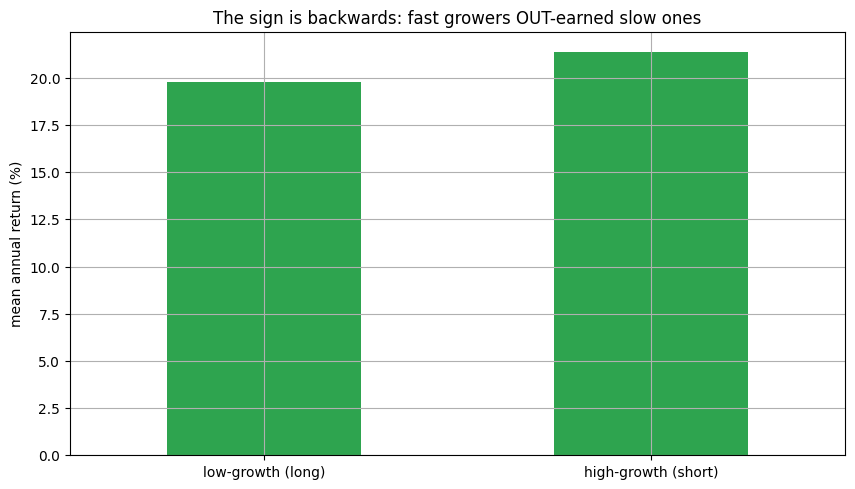

hedge (low - high): -1.62%/yr  Sharpe -0.12


In [2]:
leg = pd.DataFrame({'low-growth (long)':[st.summary(h['low_growth'])['mean']],
                    'high-growth (short)':[st.summary(h['high_growth'])['mean']]}, index=['mean annual return'])
ax = (leg.T*100).plot.bar(legend=False, rot=0, color=['#2ea44f','#c0392b'],
        title='The sign is backwards: fast growers OUT-earned slow ones')
ax.set_ylabel('mean annual return (%)'); plt.show()
print('hedge (low - high): %+.2f%%/yr  Sharpe %.2f' % (st.summary(h['hedge'])['mean']*100, st.summary(h['hedge'])['sharpe']))

## 4 · The teardown

The long-short loses money over 2005–2025 — not because the year was unlucky, but because on liquid large caps the premium isn't there to harvest.

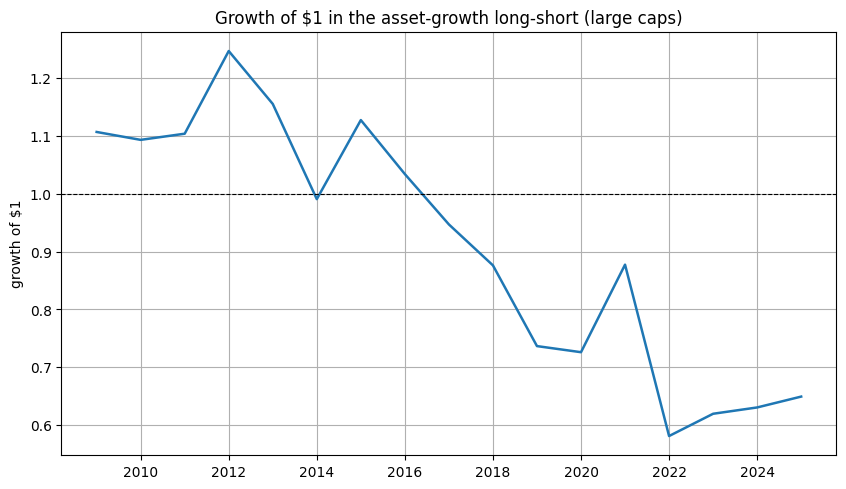

In [3]:
eq=(1+h['hedge']).cumprod()
ax=eq.plot(title='Growth of $1 in the asset-growth long-short (large caps)',lw=1.8)
ax.axhline(1.0,color='k',lw=.8,ls='--'); ax.set_ylabel('growth of $1'); plt.show()

**Read it plainly.** A line that drifts *down*. The vendor's 0.835 came from a corner of the market — tiny, illiquid stocks — that a tradable strategy can't reach. Move to names you could hold and the edge is gone.

## 5 · The verdict

**Signal: None** — no premium on tradable large caps (the sign even flips). **Tradability: Mirage** — 0.835 lives where you can't trade. **Replicates?: Busted.**

## 6 · Could you actually trade it?

Not the headline version. To get the advertised Sharpe you'd need to short hundreds of micro-caps — wide spreads, hard-to-borrow, and the exact names most prone to survivorship and data errors. The liquid version doesn't pay.

## 7 · Going further 🚪

The quants notebook gives the three reasons (micro-cap concentration, the investment factor, survivorship) and the numbers. Next: [Study 45 Vanishing-Act](../../45-vanishing-act/) — the size premium, the anomaly that *defined* post-publication decay.